In [112]:
# Data manipulation
import pandas as pd

# Text processing
import re
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from textblob import Word
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.sentiment import SentimentIntensityAnalyzer
# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import LinearSVC

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns




[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [113]:
df = pd.read_csv("Reviews.csv")
print(df.shape)
df.head()

(568454, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


# 2. Data  Exploration

In [114]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


,0
Id,0
ProductId,0
UserId,0
ProfileName,26
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,27
Text,0


data cleaning

In [115]:
df = df.dropna()
print(df.shape)

(568401, 10)


In [116]:
df = df[["Score", "ProductId", "Text","Time"]]
df.head()

,Score,ProductId,Text,Time
0,5,B001E4KFG0,I have bought several of the Vitality canned d...,1303862400
1,1,B00813GRG4,Product arrived labeled as Jumbo Salted Peanut...,1346976000
2,4,B000LQOCH0,This is a confection that has been around a fe...,1219017600
3,2,B000UA0QIQ,If you are looking for the secret ingredient i...,1307923200
4,5,B006K2ZZ7K,Great taffy at a great price. There was a wid...,1350777600


In [117]:
def score_to_sentiment(score):
     if score >= 4:
        return "Positive"
     else:
        return "Negative"

df["Sentiment"] = df["Score"].map(score_to_sentiment)
df["Sentiment"].value_counts()

,count
Sentiment,
Positive,443756
Negative,124645


In [118]:
df["Date"] = pd.to_datetime(df["Time"], unit="s")
df["Year"] = df["Date"].dt.year
df["Year"].value_counts().sort_index()

,count
Year,
1999,6
2000,32
2001,13
2002,73
2003,132
2004,561
2005,1335
2006,6671
2007,22275


In [119]:
!pip install textblob

In [120]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Lowercase conversion
    text = text.lower()

    # 2. Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # 3. Remove numbers
    text = re.sub(r'\d+', '', text)

    # 4. Tokenization
    words = text.split()

    # 5. Remove stopwords
    words = [w for w in words if w not in stop_words]

    # 6. Lemmatization using TextBlob
    words = [Word(w).lemmatize() for w in words]

    return ' '.join(words)

# Apply preprocessing to the entire dataset
df["Text_Clean"] = df["Text"].apply(preprocess_text)

# Remove rare words (appearing less than 10 times)
freq = pd.Series(' '.join(df["Text_Clean"]).split()).value_counts()
rare_words = set(freq[freq < 10].index)
df["Text_Clean"] = df["Text_Clean"].apply(
    lambda x: " ".join(w for w in x.split() if w not in rare_words)
)

# Verify results
df[["Text", "Text_Clean"]].head(3)

,Text,Text_Clean
0,I have bought several of the Vitality canned d...,bought several vitality canned dog food produc...
1,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled jumbo salted peanut ac...
2,This is a confection that has been around a fe...,confection around century light pillowy citrus...


In [121]:
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [122]:
# Apply VADER sentiment scoring to the entire dataset
df["Polarity"] = df["Text_Clean"].apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

# Verify results
df[["Text_Clean", "Polarity", "Sentiment"]].head()

,Text_Clean,Polarity,Sentiment
0,bought several vitality canned dog food produc...,0.9413,Positive
1,product arrived labeled jumbo salted peanut ac...,-0.1027,Negative
2,confection around century light pillowy citrus...,0.8624,Positive
3,looking secret ingredient robitussin believe f...,0.4404,Negative
4,great taffy great price wide assortment yummy ...,0.9468,Positive


In [111]:
# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95
)

# Transform text into numerical features
X = tfidf.fit_transform(df["Text_Clean"])

# Define target variable
y = df["Sentiment"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Shape de X: (568401, 10000)
Shape de y: (568401,)


data vis

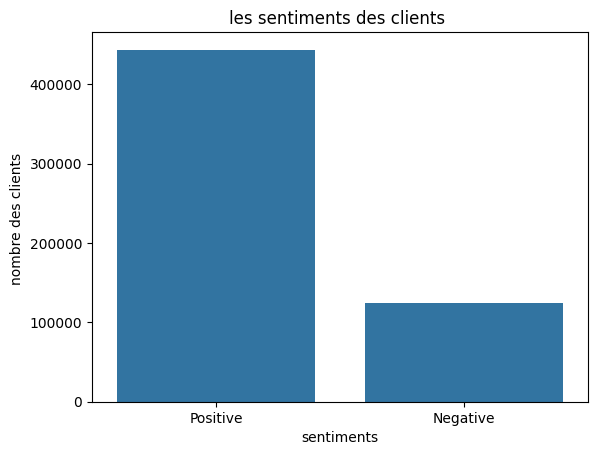

In [123]:
# Sentiment distribution
sns.countplot(x="Sentiment", data=df)
plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

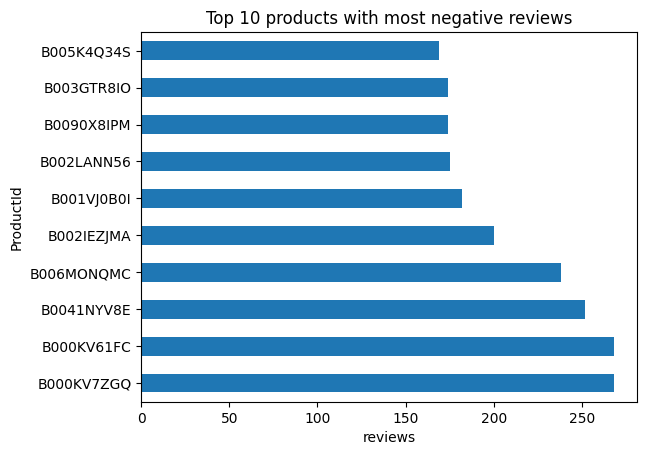

In [124]:
# Filter negative reviews
negative = df[df["Sentiment"] == "Negative"]

# Top 10 products with most negative reviews
top_negative = negative["ProductId"].value_counts().head(10)

# Plot
top_negative.plot(kind="barh")
plt.title("Top 10 products with most negative reviews")
plt.ylabel("ProductId")
plt.xlabel("reviews")
plt.show()

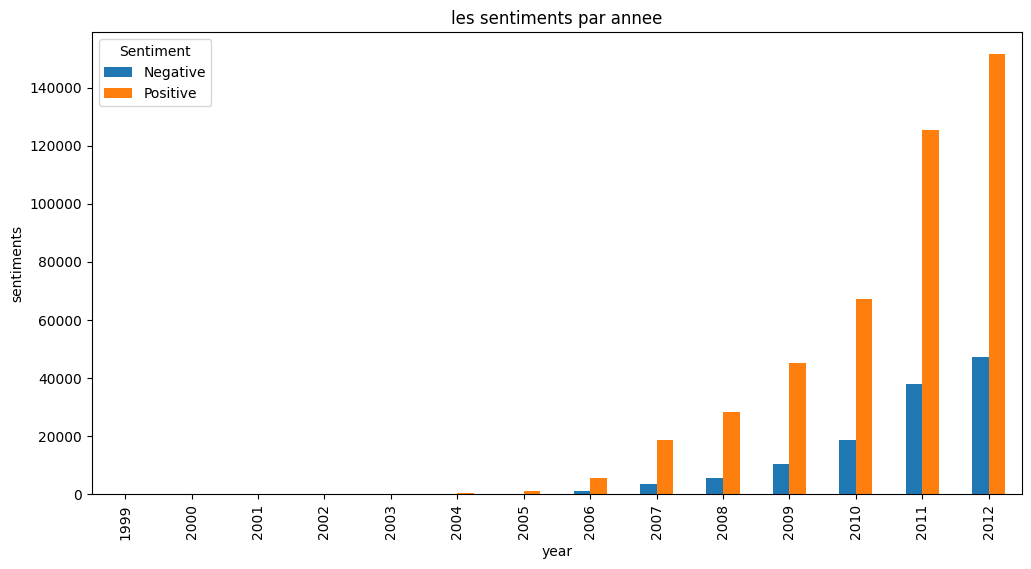

In [125]:
# Sentiment trends over the years
sentiment_par_annee = df.groupby(["Year", "Sentiment"]).size().unstack()

sentiment_par_annee.plot(kind="bar", figsize=(12, 6))
plt.title("Sentiment Trends by Year")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.show()

In [126]:
# Complete sentiment analysis by product
sentiment_produit = df.groupby(
    ["ProductId", "Sentiment"]
).size().unstack(fill_value=0)

# Add total reviews and percentage columns
sentiment_produit["Total"] = sentiment_produit.sum(axis=1)
sentiment_produit["% Positive"] = (
    sentiment_produit["Positive"] / sentiment_produit["Total"] * 100
).round(1)
sentiment_produit["% Negative"] = (
    sentiment_produit["Negative"] / sentiment_produit["Total"] * 100
).round(1)

# Sort by total reviews
sentiment_produit = sentiment_produit.sort_values(
    "Total", ascending=False
)

# Display top 20 products
sentiment_produit.head(20)

Sentiment,Negative,Positive,Total,% Positifs,% Negative
ProductId,,,,,
B007JFMH8M,72,841,913,92.1,7.9
B002QWP89S,60,572,632,90.5,9.5
B002QWP8H0,60,572,632,90.5,9.5
B002QWHJOU,60,572,632,90.5,9.5
B0026RQTGE,60,572,632,90.5,9.5
B003B3OOPA,38,585,623,93.9,6.1
B001EO5Q64,28,539,567,95.1,4.9
B006HYLW32,105,459,564,81.4,18.6
B001RVFEP2,105,459,564,81.4,18.6


In [127]:
# Top 5 most positively reviewed products
top_positif = df[df["Sentiment"] == "Positive"]["ProductId"].value_counts().head(5)

# Top 5 most negatively reviewed products
top_negatif = df[df["Sentiment"] == "Negative"]["ProductId"].value_counts().head(5)

print("Top 5 most appreciated products:")
print(top_positif)
print("\nTop 5 most criticized products:")
print(top_negatif)

Top 5 produits les plus appréciés :
ProductId
B007JFMH8M    841
B003B3OOPA    585
B002QWP8H0    572
B0026RQTGE    572
B002QWHJOU    572
Name: count, dtype: int64

Top 5 produits les plus critiqués :
ProductId
B000KV7ZGQ    268
B000KV61FC    268
B0041NYV8E    252
B006MONQMC    238
B002IEZJMA    200
Name: count, dtype: int64


TEST TRAIN SPLIT

In [128]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(454720, 10000)
(113681, 10000)


Logistic Regression

## Model 1 — Logistic Regression without Balanced Class Weight

Objective: Maximize overall accuracy
Trade-off: Higher precision, lower recall for negative class
Best for: Automated response systems requiring high precision

In [135]:
modele_lr = LogisticRegression(
    max_iter=1000,
    random_state=42,

)

modele_lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

## Model 2 — Logistic Regression with Balanced Class Weight

Objective: Maximize detection of negative reviews
Trade-off: Higher recall for negative class, lower precision
Best for: Companies that want to catch all negative feedback

In [133]:
modele_lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

modele_lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [136]:
y_pred = modele_lr.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9021296434760426
              precision    recall  f1-score   support

    Negative       0.83      0.69      0.76     24912
    Positive       0.92      0.96      0.94     88769

    accuracy                           0.90    113681
   macro avg       0.87      0.83      0.85    113681
weighted avg       0.90      0.90      0.90    113681



SVM

In [132]:
modele_svm = LinearSVC(
    random_state=42,
    class_weight="balanced",
    max_iter=1000
)

modele_svm.fit(X_train, y_train)
y_pred_svm = modele_svm.predict(X_test)

print("SVM Results:")
print(accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Results:
0.8780359074955357
              precision    recall  f1-score   support

    Negative       0.67      0.88      0.76     24912
    Positive       0.96      0.88      0.92     88769

    accuracy                           0.88    113681
   macro avg       0.82      0.88      0.84    113681
weighted avg       0.90      0.88      0.88    113681



# Conclusion & Business Recommendations

## Models Summary

| Model | Accuracy | Recall Negative | Best For |
|---|---|---|---|
| LR Balanced | 88% | 87% | Product improvement & monitoring |
| LR Non-Balanced | 90% | 69% | Automated customer response systems |

## Key Findings

1. **78% of reviews are positive** — overall strong customer satisfaction
2. **Top performing products:** B007JFMH8M (92% positive, 841 reviews)
   and B003B3OOPA (94% positive, 623 reviews)
3. **Critical products requiring urgent attention:**
   - B000KV61FC and B000KV7ZGQ — only 52% positive with 556 reviews each
   - B005K4Q1YA — 31% negative rate with 537 reviews
4. **Negative reviews represent 22%** of all reviews — significant opportunity
   for improvement

## Business Recommendations

1. **Immediate action** — Investigate products B000KV61FC and B000KV7ZGQ
   — nearly 50% negative reviews is critical
2. **Use Model 1 (Balanced)** to automatically flag negative reviews
   for quality control teams
3. **Use Model 2 (Non-Balanced)** for automated customer response systems
4. **Monitor sentiment quarterly** — negative reviews grew significantly
   between 2006-2012
5. **Learn from top products** — analyze what makes B007JFMH8M
   so successful and apply to underperforming products